# 🌙 야간 이미지 객체 탐지 — 데이터 파이프라인

**목표:** COCO val2017 이미지를 감마 보정으로 야간 이미지로 합성하고 Google Drive에 저장

**파이프라인:**
```
COCO val2017 원본 이미지
        ↓ 감마 보정 (γ = 2.0 ~ 5.0)
야간 합성 이미지
        ↓ 저장
Google Drive (data/raw/, data/synthetic/)
```

**실행 순서:** 위에서 아래로 셀 순서대로 실행하면 됩니다.

## Step 1. Google Drive 연동
Drive에 데이터를 저장해서 세션이 끊겨도 유지되게 합니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Drive 내 프로젝트 폴더 경로 설정
PROJECT_DIR = '/content/drive/MyDrive/night-detection-project'
RAW_DIR     = os.path.join(PROJECT_DIR, 'data/raw')
SYNTH_DIR   = os.path.join(PROJECT_DIR, 'data/synthetic')

# 폴더 생성
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(SYNTH_DIR, exist_ok=True)

print('✅ Drive 연동 완료')
print(f'   RAW    → {RAW_DIR}')
print(f'   SYNTH  → {SYNTH_DIR}')

Mounted at /content/drive
✅ Drive 연동 완료
   RAW    → /content/drive/MyDrive/night-detection-project/data/raw
   SYNTH  → /content/drive/MyDrive/night-detection-project/data/synthetic


## Step 2. 라이브러리 설치 및 임포트

In [2]:
!pip install pycocotools -q

import os, json, zipfile, requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
from tqdm import tqdm

print('✅ 라이브러리 임포트 완료')

✅ 라이브러리 임포트 완료


## Step 3. COCO val2017 다운로드

- 이미지: ~1GB
- Annotation: ~241MB
- 다운로드 후 Drive에 저장됩니다.

In [3]:
COCO_DIR       = os.path.join(RAW_DIR, 'coco')
IMG_DIR        = os.path.join(COCO_DIR, 'images/val2017')
ANNO_DIR       = os.path.join(COCO_DIR, 'annotations')

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(ANNO_DIR, exist_ok=True)

def download_and_extract(url, dest_dir, filename):
    zip_path = os.path.join(dest_dir, filename)
    if os.path.exists(zip_path):
        print(f'⏭️  이미 존재: {filename}')
    else:
        print(f'⬇️  다운로드 중: {filename} ...')
        r = requests.get(url, stream=True)
        with open(zip_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f'✅ 다운로드 완료: {filename}')

    print(f'📦 압축 해제 중: {filename} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dest_dir)
    print(f'✅ 압축 해제 완료')

# 이미지 다운로드 (약 1GB, 시간이 걸립니다)
download_and_extract(
    'http://images.cocodataset.org/zips/val2017.zip',
    COCO_DIR,
    'val2017.zip'
)

# Annotation 다운로드
download_and_extract(
    'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
    COCO_DIR,
    'annotations_trainval2017.zip'
)

print('\n✅ COCO val2017 다운로드 완료!')

⬇️  다운로드 중: val2017.zip ...
✅ 다운로드 완료: val2017.zip
📦 압축 해제 중: val2017.zip ...
✅ 압축 해제 완료
⬇️  다운로드 중: annotations_trainval2017.zip ...
✅ 다운로드 완료: annotations_trainval2017.zip
📦 압축 해제 중: annotations_trainval2017.zip ...
✅ 압축 해제 완료

✅ COCO val2017 다운로드 완료!


## Step 4. COCO 데이터셋 파싱 확인
Annotation을 로드하고 데이터 구조를 확인합니다.

In [4]:
ANNO_PATH = os.path.join(COCO_DIR, 'annotations/instances_val2017.json')
coco = COCO(ANNO_PATH)

# 기본 정보 출력
img_ids = coco.getImgIds()
cat_ids = coco.getCatIds()
cats    = coco.loadCats(cat_ids)

print(f'📊 COCO val2017 데이터셋 정보')
print(f'   전체 이미지 수  : {len(img_ids)}장')
print(f'   카테고리 수     : {len(cats)}개')
print(f'   카테고리 목록   : {[c["name"] for c in cats[:10]]} ...')

# 이미지 1장 샘플 확인
sample = coco.loadImgs(img_ids[0])[0]
print(f'\n🖼️  샘플 이미지 정보')
print(f'   파일명 : {sample["file_name"]}')
print(f'   크기   : {sample["width"]} x {sample["height"]}')

loading annotations into memory...
Done (t=0.73s)
creating index...
index created!
📊 COCO val2017 데이터셋 정보
   전체 이미지 수  : 5000장
   카테고리 수     : 80개
   카테고리 목록   : ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light'] ...

🖼️  샘플 이미지 정보
   파일명 : 000000397133.jpg
   크기   : 640 x 427


## Step 5. 감마 보정으로 야간 이미지 합성

감마 보정 공식:
$$I_{low}(x) = I(x)^{\gamma}$$

- γ가 클수록 더 어두워집니다 (2.0 ~ 5.0)
- 기본값: γ = 3.0

/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2431/1952430178.py:32: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layou

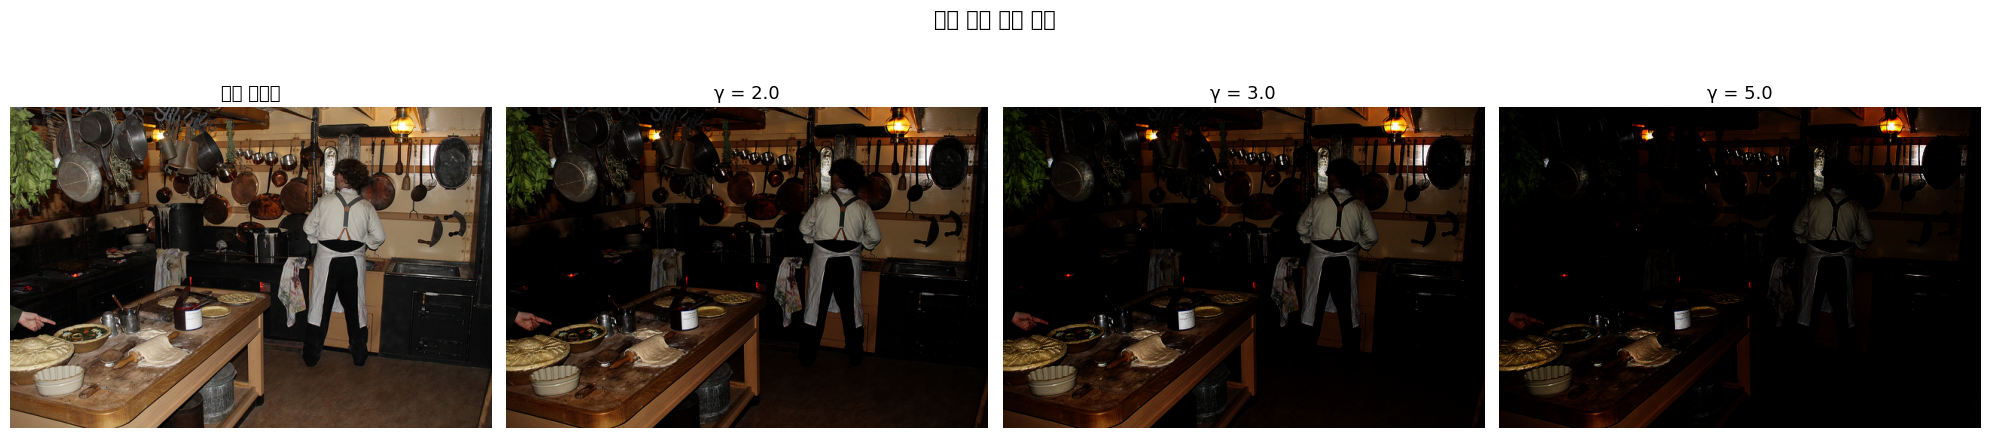

✅ 감마값 비교 이미지 저장 완료


In [10]:
def apply_gamma_correction(image: Image.Image, gamma: float = 3.0) -> Image.Image:
    """
    감마 보정으로 야간 이미지를 합성합니다.
    gamma가 클수록 더 어두워집니다.
    """
    img_array = np.array(image).astype(np.float32) / 255.0
    img_dark  = np.power(img_array, gamma)
    img_dark  = (img_dark * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(img_dark)


# 감마값별 결과 비교 시각화 (샘플 1장)
# IMG_DIR 변수가 이전 셀에서 잘못 정의되어, 현재 셀에서 올바른 경로로 재정의합니다.
IMG_DIR = os.path.join(COCO_DIR, 'val2017')
sample_path = os.path.join(IMG_DIR, sample['file_name'])
original    = Image.open(sample_path).convert('RGB')

gammas = [2.0, 3.0, 5.0]
fig, axes = plt.subplots(1, len(gammas) + 1, figsize=(20, 5))

axes[0].imshow(original)
axes[0].set_title('원본 이미지', fontsize=13)
axes[0].axis('off')

for i, g in enumerate(gammas):
    dark = apply_gamma_correction(original, gamma=g)
    axes[i+1].imshow(dark)
    axes[i+1].set_title(f'γ = {g}', fontsize=13)
    axes[i+1].axis('off')

plt.suptitle('감마 보정 결과 비교', fontsize=15, fontweight='bold')
plt.tight_layout()

# 결과 이미지를 저장할 'results' 디렉토리가 없으면 생성합니다.
os.makedirs(os.path.join(PROJECT_DIR, 'results'), exist_ok=True)
plt.savefig(os.path.join(PROJECT_DIR, 'results/gamma_comparison.png'), dpi=150)
plt.show()
print('✅ 감마값 비교 이미지 저장 완료')

## Step 6. 전체 이미지 야간 합성 자동화

전체 5,000장에 감마 보정을 적용해서 저장합니다.
시간이 걸릴 수 있습니다 (약 10~20분).

In [ ]:
GAMMA       = 3.0   # 최종 감마값 (Step 5 결과 보고 조정)
MAX_IMAGES  = 5000  # 전체 사용할 이미지 수 (줄이려면 숫자 낮추기)

synth_img_dir = os.path.join(SYNTH_DIR, f'coco_gamma{GAMMA}')
os.makedirs(synth_img_dir, exist_ok=True)

img_ids_subset = img_ids[:MAX_IMAGES]
failed = []

for img_id in tqdm(img_ids_subset, desc='야간 합성 진행중'):
    img_info  = coco.loadImgs(img_id)[0]
    src_path  = os.path.join(IMG_DIR, img_info['file_name'])
    dst_path  = os.path.join(synth_img_dir, img_info['file_name'])

    if os.path.exists(dst_path):
        continue  # 이미 처리된 이미지는 스킵

    try:
        img  = Image.open(src_path).convert('RGB')
        dark = apply_gamma_correction(img, gamma=GAMMA)
        dark.save(dst_path)
    except Exception as e:
        failed.append(img_info['file_name'])

print(f'\n✅ 야간 합성 완료!')
print(f'   처리 완료 : {MAX_IMAGES - len(failed)}장')
print(f'   실패      : {len(failed)}장')
print(f'   저장 위치 : {synth_img_dir}')

## Step 7. 최종 결과 확인
원본 vs 야간 이미지 랜덤 5장 비교

In [ ]:
import random

sample_ids = random.sample(img_ids_subset, 5)
fig, axes  = plt.subplots(5, 2, figsize=(12, 20))

for i, img_id in enumerate(sample_ids):
    img_info = coco.loadImgs(img_id)[0]
    fname    = img_info['file_name']

    original = Image.open(os.path.join(IMG_DIR, fname)).convert('RGB')
    dark     = Image.open(os.path.join(synth_img_dir, fname)).convert('RGB')

    axes[i][0].imshow(original)
    axes[i][0].set_title('원본' if i == 0 else '', fontsize=12)
    axes[i][0].axis('off')

    axes[i][1].imshow(dark)
    axes[i][1].set_title(f'야간 합성 (γ={GAMMA})' if i == 0 else '', fontsize=12)
    axes[i][1].axis('off')

plt.suptitle('원본 vs 야간 합성 이미지 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'results/original_vs_synthetic.png'), dpi=150)
plt.show()
print('✅ 최종 결과 저장 완료')
print(f'\n📁 데이터 저장 위치')
print(f'   원본    → {IMG_DIR}')
print(f'   야간    → {synth_img_dir}')
print(f'   결과    → {PROJECT_DIR}/results/')